In [1]:
# AI4I 2020 Predictive Maintenance Dataset
## Exploratory Data Analysis (EDA)

## This notebook performs an exploratory analysis of the AI4I 2020 Predictive Maintenance dataset before building the Artificial Neural Network (ANN) model.

In [3]:
## importing all the required libraries...
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)

In [4]:
## loading the dataset

dataset_path = Path("../dataset/ai4i2020.csv")

df = pd.read_csv(dataset_path)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
## dataset shape
print("Dataset Shape :", df.shape)

Dataset Shape : (10000, 14)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
# Target Variable Analysis, session 2.... machine type distribution, histogram, boxplots...

##In this section, we analyze the distribution of the target variable (Machine Failure) to determine whether the dataset is balanced or imbalanced.

In [13]:
# Machine Failure Count

df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

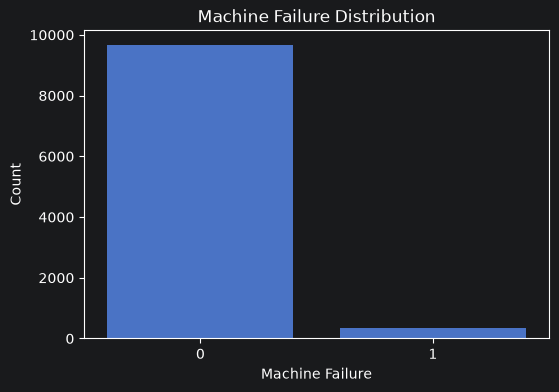

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

In [15]:
### Observation

##Observe whether the dataset contains significantly more non-failure samples than failure samples. This will help us decide later if class balancing techniques are required.

In [16]:
# Machine Type Distribution

## This section analyzes the distribution of machine categories (L, M and H).

In [17]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

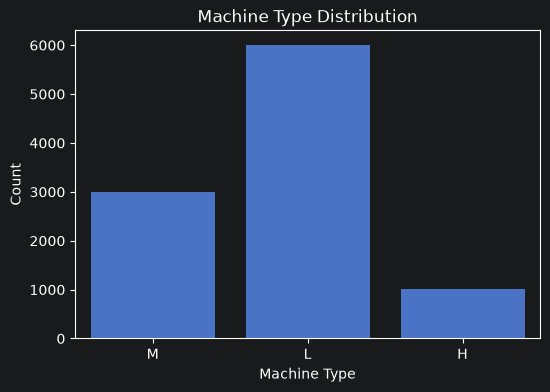

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Type"
)

plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Count")

plt.show()

In [19]:
### Observation

# Observe whether Low (L), Medium (M) and High (H) quality machines are equally represented in the dataset.

In [20]:
# Numerical Feature Distribution

# The following histograms show the distribution of numerical features in the dataset.

In [21]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

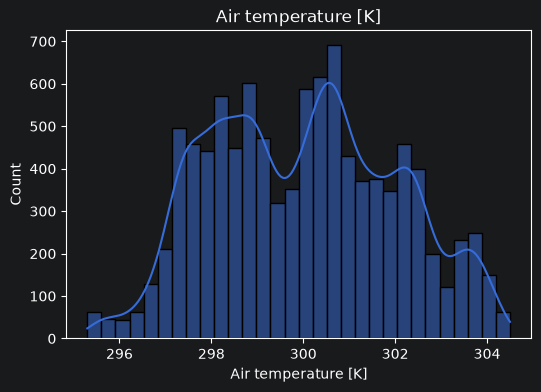

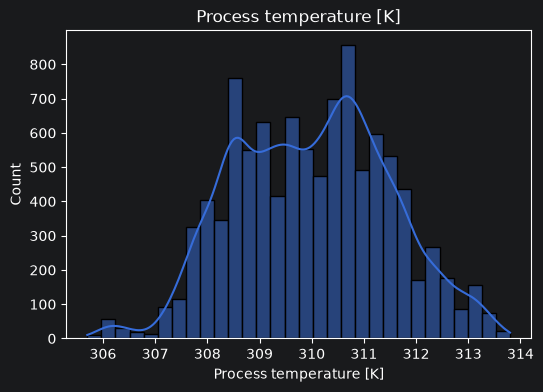

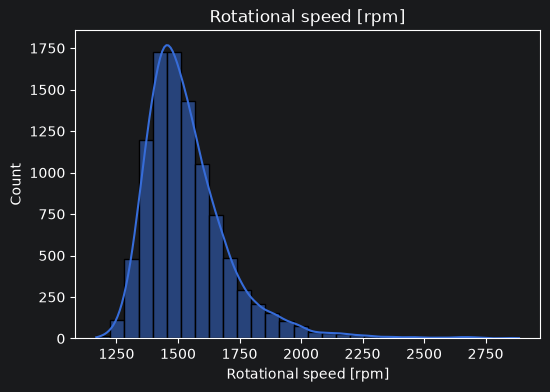

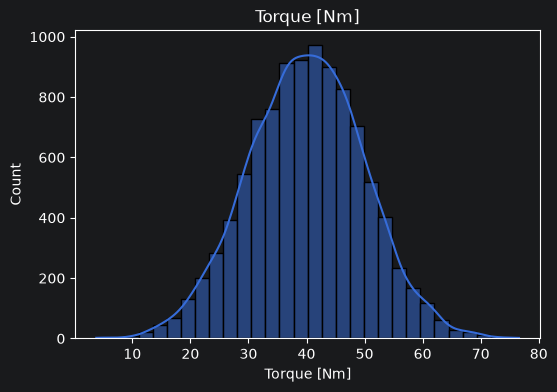

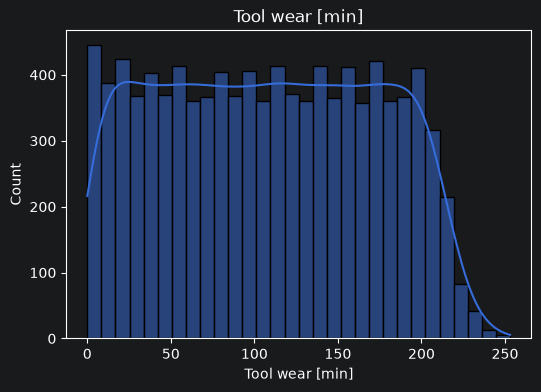

In [22]:
for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[feature],
        bins=30,
        kde=True
    )

    plt.title(feature)

    plt.show()

In [23]:
### Observation

##Observe whether the numerical features follow a normal distribution, contain skewness, or exhibit unusual patterns that may influence preprocessing decisions.

In [25]:
## session -3
# Correlation Analysis

#Correlation analysis helps us understand the relationship between numerical variables. It also shows whether any features are strongly related to the target variable.

In [26]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numerical_df.corr()

correlation_matrix

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


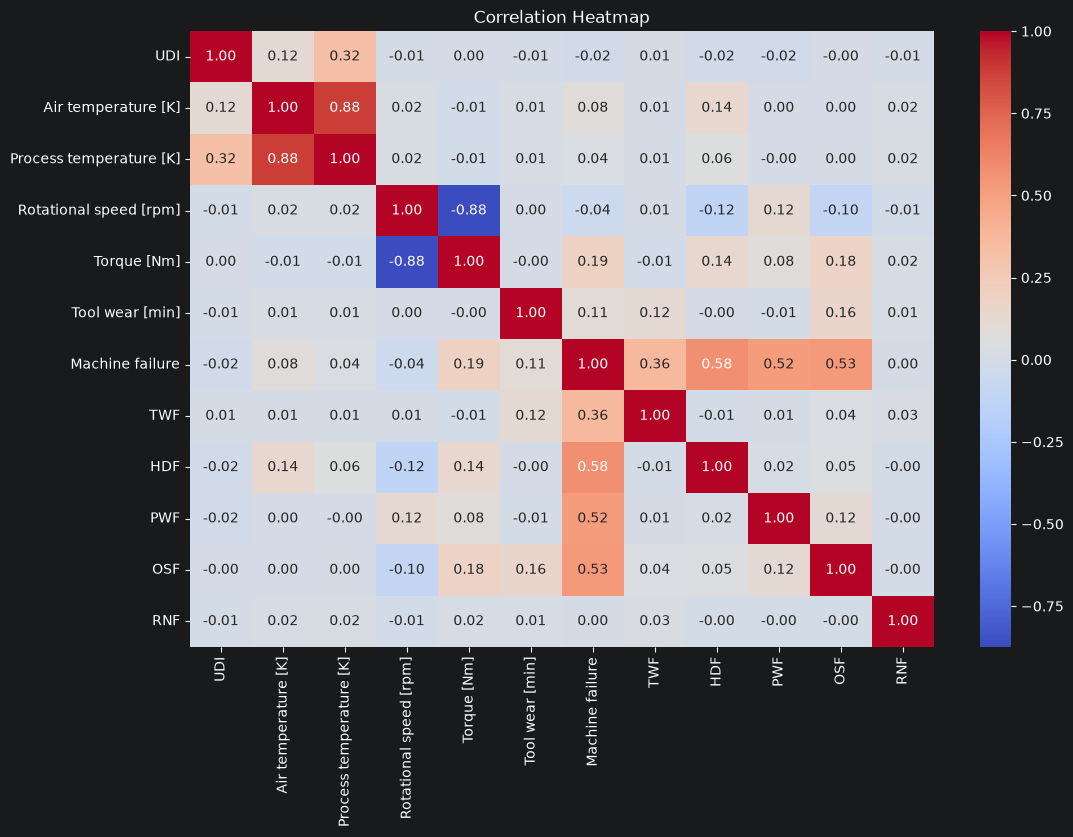

In [27]:
# using heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
### Observation

#Analyze whether any numerical features have strong positive or negative correlations. Pay special attention to the relationship between the operational features and the target variable (Machine Failure).

In [29]:
# Outlier Detection using Boxplots

#Boxplots help identify possible outliers in numerical features.

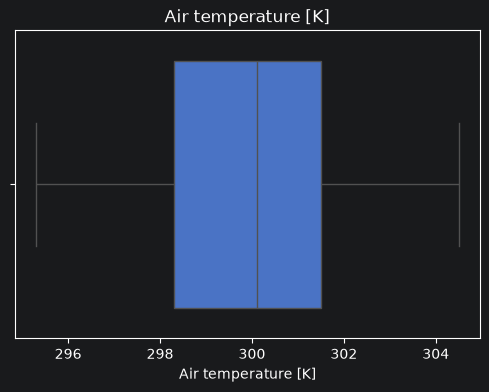

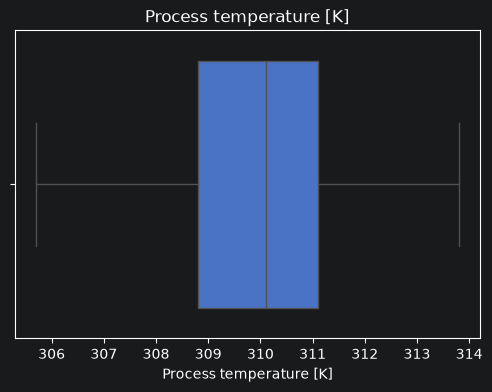

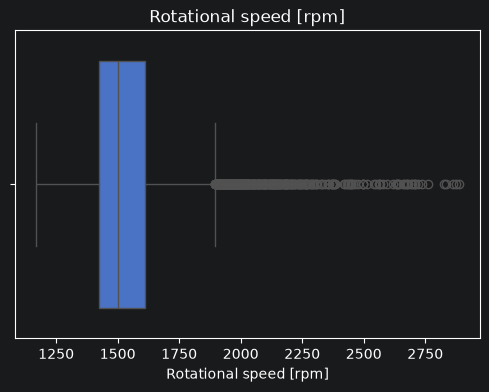

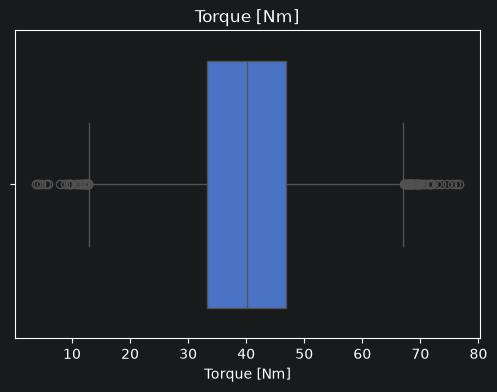

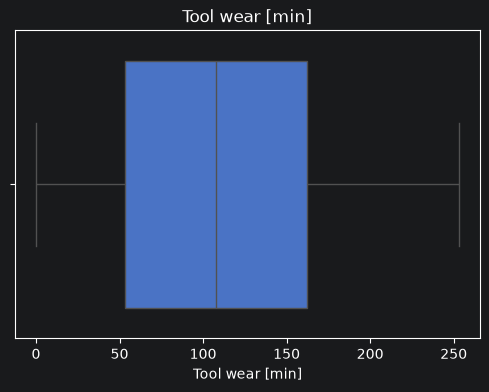

In [30]:
for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(feature)

    plt.show()

In [31]:
### Observation

#Observe whether extreme values are present. These may represent genuine machine operating conditions or potential outliers that should be investigated before model training.

In [32]:
# Feature Distribution with Respect to Machine Failure

#The following boxplots compare each numerical feature for machines that failed versus those that did not fail.

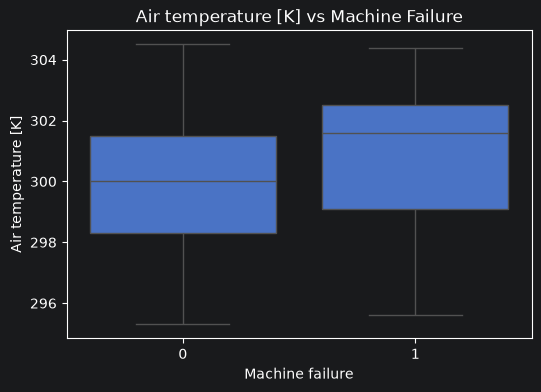

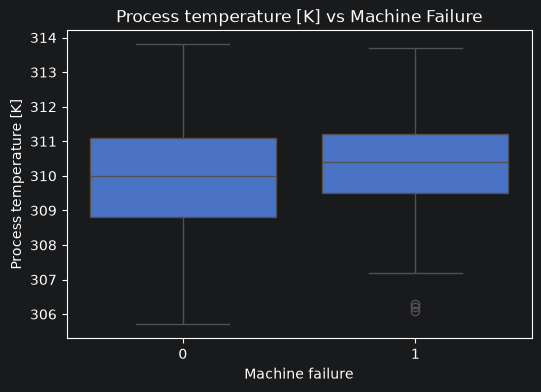

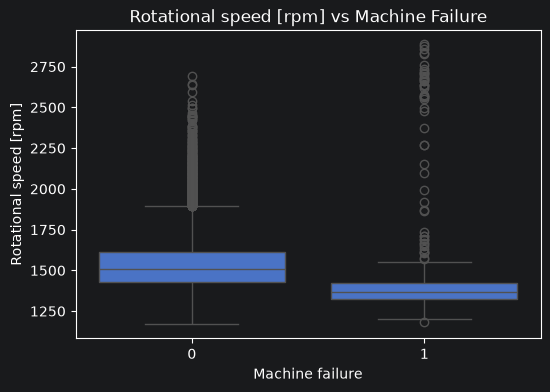

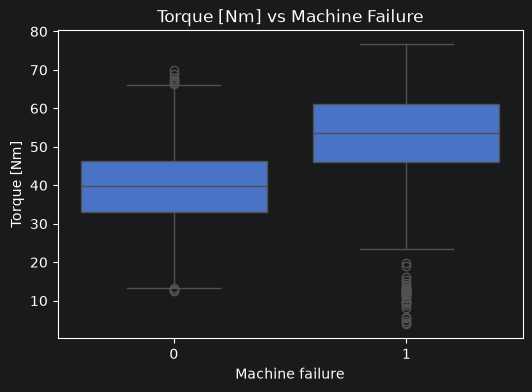

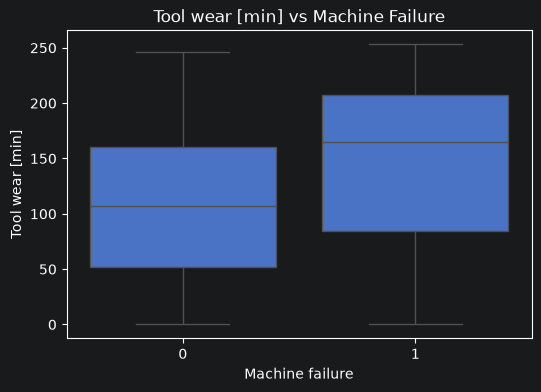

In [33]:
for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )

    plt.title(f"{feature} vs Machine Failure")

    plt.show()

In [34]:
### Observation

#Compare the distributions of each feature for failed and non-failed machines. Differences between the two groups indicate that the feature may be useful for predicting machine failure.

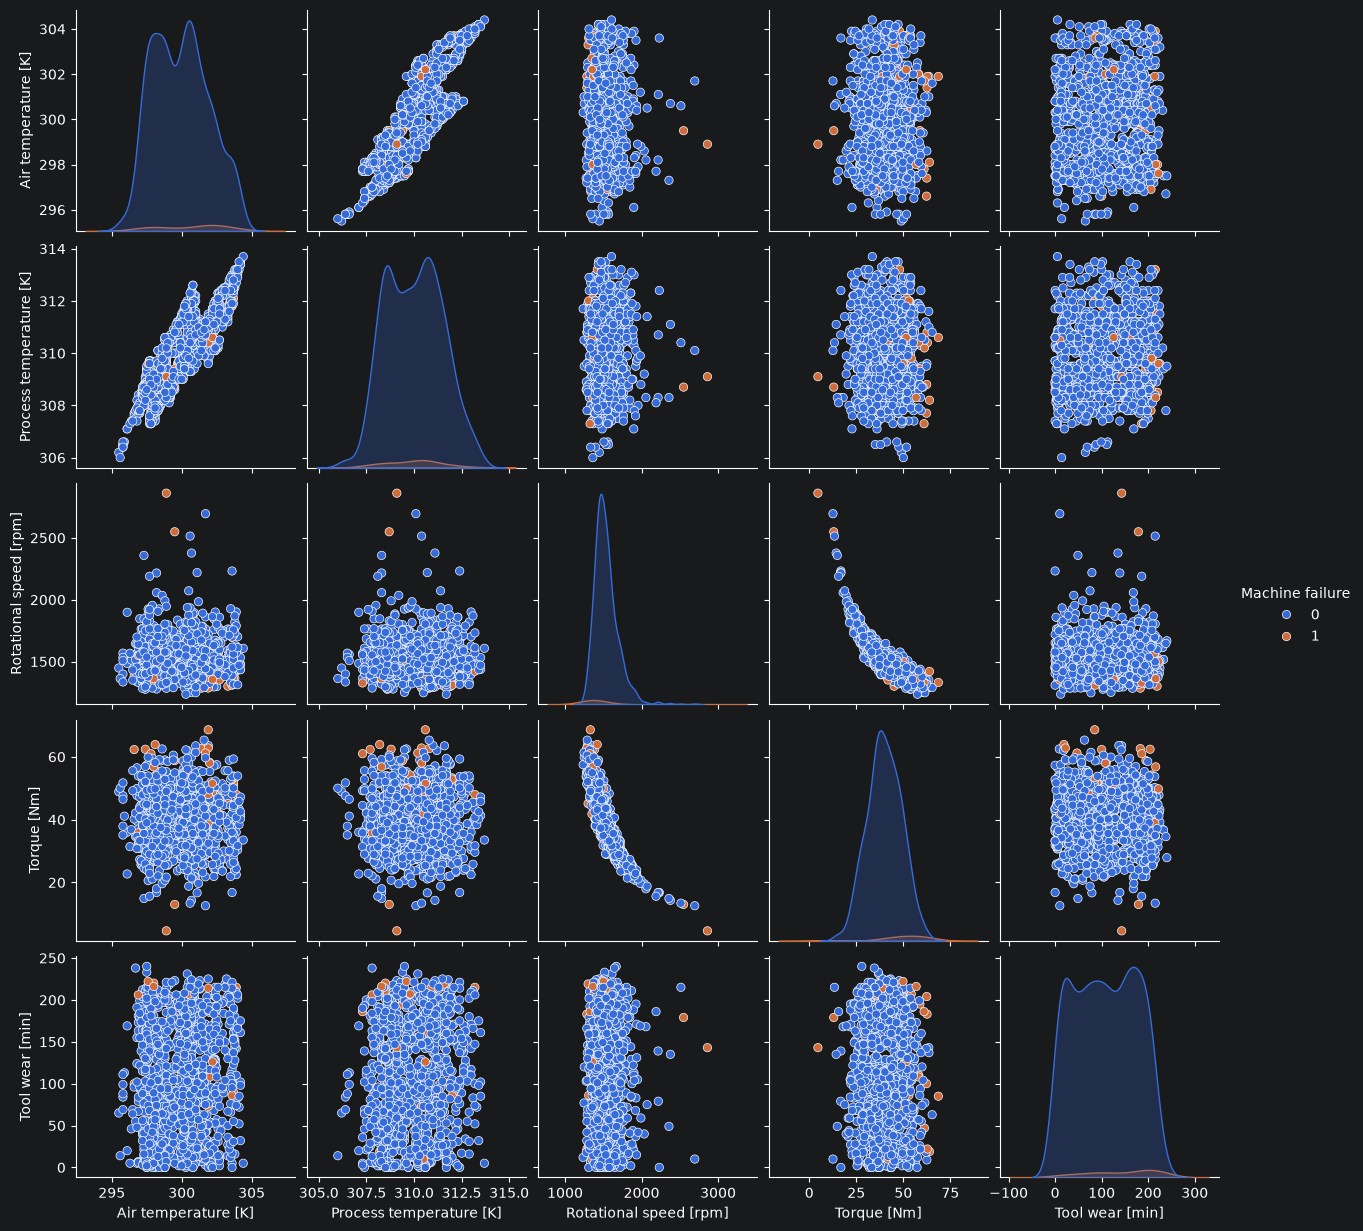

In [36]:
0#0 Pairwise Relationship between Features

sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df,
    vars=numerical_features,
    hue="Machine failure"
)

plt.show()

# EDA Summary

### Key Findings

- The dataset contains 10,000 machine records with no missing values and no duplicate entries.
- The target variable (Machine Failure) is expected to be imbalanced, which will be considered during model training.
- Numerical features show meaningful variation and may require feature scaling before training the ANN.
- Outliers observed in operational variables appear to represent realistic machine behaviour rather than data entry errors.
- Machine Type is a categorical feature and will require encoding during preprocessing.
- UDI and Product ID are identifiers and will not be used as ANN input features.
- Failure subtype columns (TWF, HDF, PWF, OSF and RNF) will be excluded from training because they leak information about the target.